# Экологические модели #

*Вся плоть - трава (Исаия 40:6)*

Биологи исследуют развитие популяции организмов (травы) внутри замкнутой экосистемы (огороженного луга). Существует предельная экологическая вместимость луга.

Мы будем моделировать динамику травы логистическим уравнением:

$$ x' = r x (1-x) $$

где r - скорость размножения травы, доля - процент заполнения луга травой. 

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from math import pi

## Параметры модели ##

In [34]:
# Параметры логистического уравнения
r_values = [-2.0, -1.0, -0.5, 0.5, 1.0, 2.0]  # различные значения скорости роста
x0 = 0.5  # начальное значение (доля заполнения луга)

# Параметры интегрирования
t_start = 0.0
t_end = 10.0
dt = 0.01
t_eval = np.arange(t_start, t_end, dt)

# Параметры сезонности
r0 = 1.0      # средняя скорость роста


## Функция правой части логистического уравнения ##

In [35]:
def population_equation(t, x, r0, ra, omega):
    """
    Правая часть логистического уравнения

    dx/dt = r * x * (1 - x)

    Args:
        t: время
        x: текущая доля заполнения луга
        r: скорость роста

    Returns:
        dx/dt
    """
    r_t = r0 + ra * np.sin(omega * t)
    return r_t * x * (1 - x)

## Решение логистического уравнения методом RK45 ##

In [36]:
def solve_logistic_rk45(x0, r, t_eval):
    """
    Решение логистического уравнения методом RK45

    Args:
        x0: начальное условие
        r: параметр роста
        t_eval: точки времени для оценки решения

    Returns:
        решение в точках t_eval
    """
    sol = solve_ivp(
        lambda t, x: population_equation(t, x, r, 1, 0),
        (t_eval[0], t_eval[-1]),
        [x0],
        method='RK45',
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )
    return sol.y[0]

In [37]:
def solve_seasonal_logistic_rk45(x0, r0, ra, omega, t_eval):
    """
    Решение логистического уравнения с сезонностью методом RK45

    Args:
        x0: начальное условие
        r0, ra, omega: параметры сезонности
        t_eval: точки времени для оценки решения

    Returns:
        решение в точках t_eval
    """
    sol = solve_ivp(
        lambda t, x: population_equation(t, x, r0, ra, omega),
        (t_eval[0], t_eval[-1]),
        [x0],
        method='RK45',
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )
    return sol.y[0]

## 1. Демонстрация сходимости для разных начальных условий ##

In [38]:
print("=== Демонстрация сходимости логистического уравнения ===")
print(f"Время моделирования: {t_end} ед. времени")
print(f"Шаг интегрирования: {dt} ед. времени")
print()

# Разные начальные условия для демонстрации сходимости
initial_conditions = [0.1, 0.3, 0.5, 0.7, 0.9]

# Положительное r (рост к 1)
r_positive = 1.0
print(f"При r = {r_positive} (положительная скорость роста):")
solutions_positive = []
for x0_test in initial_conditions:
    sol = solve_logistic_rk45(x0_test, r_positive, t_eval)
    final_value = sol[-1]
    solutions_positive.append(sol)
    print(f"x₀ = {x0_test:.3f} → x_final = {final_value:.3f}")

print()

# Отрицательное r (рост к 0)
r_negative = -1.0
print(f"При r = {r_negative} (отрицательная скорость роста):")
solutions_negative = []
for x0_test in initial_conditions:
    sol = solve_logistic_rk45(x0_test, r_negative, t_eval)
    final_value = sol[-1]
    solutions_negative.append(sol)
    print(f"x₀ = {x0_test:.3f} → x_final = {final_value:.3f}")

=== Демонстрация сходимости логистического уравнения ===
Время моделирования: 10.0 ед. времени
Шаг интегрирования: 0.01 ед. времени

При r = 1.0 (положительная скорость роста):
x₀ = 0.100 → x_final = 1.000
x₀ = 0.300 → x_final = 1.000
x₀ = 0.500 → x_final = 1.000
x₀ = 0.700 → x_final = 1.000
x₀ = 0.900 → x_final = 1.000

При r = -1.0 (отрицательная скорость роста):
x₀ = 0.100 → x_final = 0.000
x₀ = 0.300 → x_final = 0.000
x₀ = 0.500 → x_final = 0.000
x₀ = 0.700 → x_final = 0.000
x₀ = 0.900 → x_final = 0.000


## 2. Графики для разных значений r при фиксированном x0 = 0.5 ##


=== Построение графиков для разных значений r ===


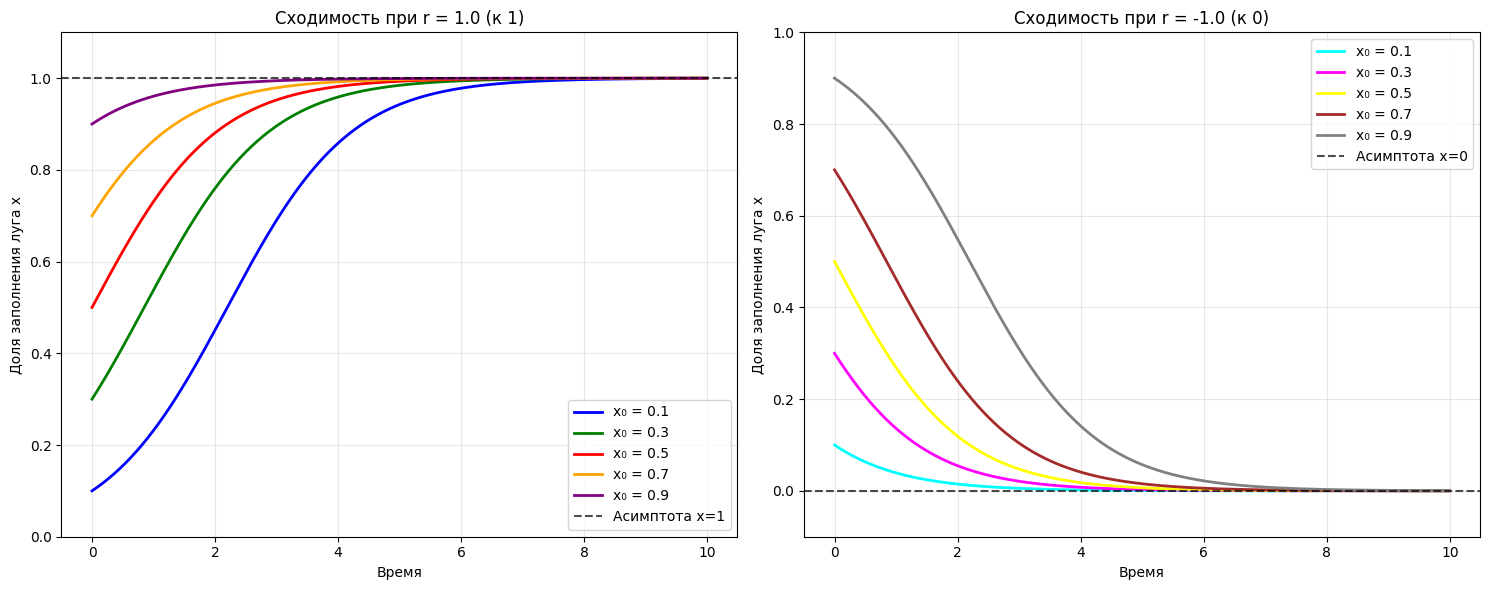

График сходимости сохранен как 'logistic_convergence.png'


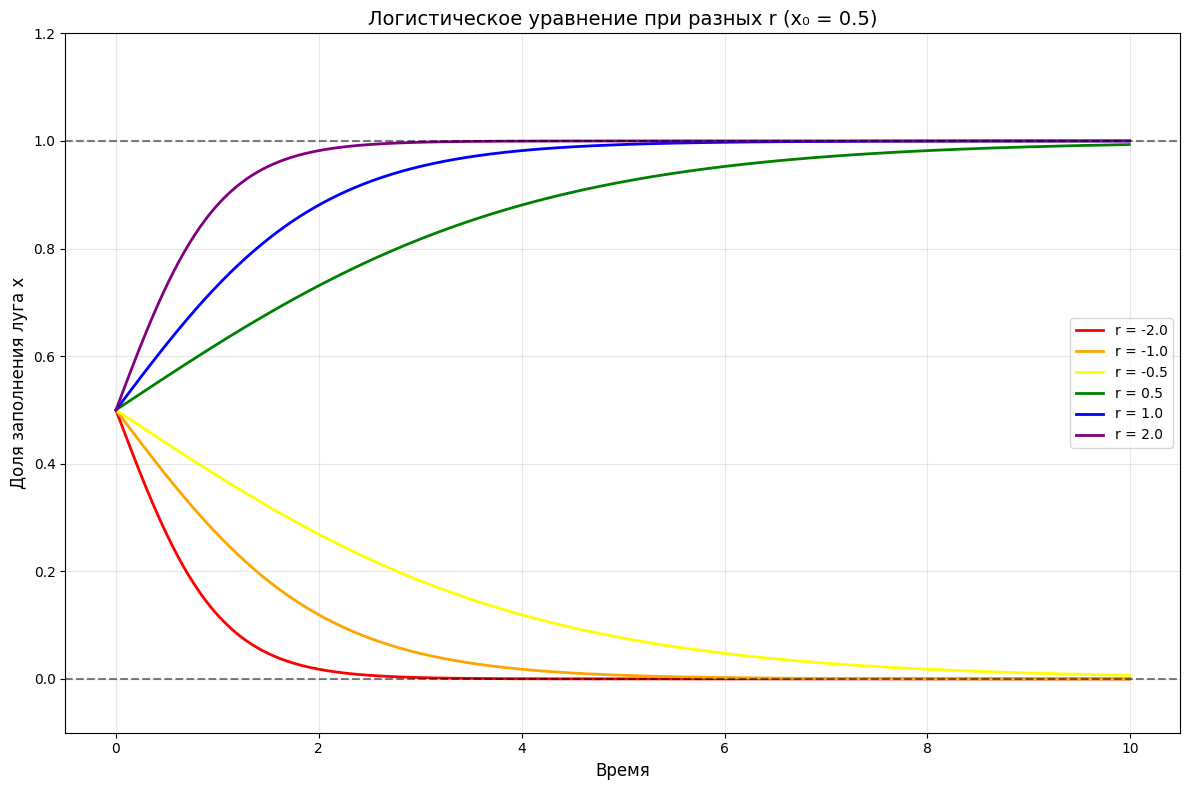

График для разных r сохранен как 'logistic_different_r.png'


In [39]:
print("\n=== Построение графиков для разных значений r ===")

# Создаем фигуру для графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График для сходимости к разным значениям
colors_pos = ['blue', 'green', 'red', 'orange', 'purple']
colors_neg = ['cyan', 'magenta', 'yellow', 'brown', 'gray']

ax1.set_title(f'Сходимость при r = {r_positive} (к 1)', fontsize=12)
ax1.set_xlabel('Время')
ax1.set_ylabel('Доля заполнения луга x')
ax1.grid(True, alpha=0.3)
for i, (x0_test, sol) in enumerate(zip(initial_conditions, solutions_positive)):
    ax1.plot(t_eval, sol, color=colors_pos[i],
             label=f'x₀ = {x0_test:.1f}', linewidth=2)
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.7, label='Асимптота x=1')
ax1.legend()
ax1.set_ylim(0, 1.1)

ax2.set_title(f'Сходимость при r = {r_negative} (к 0)', fontsize=12)
ax2.set_xlabel('Время')
ax2.set_ylabel('Доля заполнения луга x')
ax2.grid(True, alpha=0.3)
for i, (x0_test, sol) in enumerate(zip(initial_conditions, solutions_negative)):
    ax2.plot(t_eval, sol, color=colors_neg[i],
             label=f'x₀ = {x0_test:.1f}', linewidth=2)
ax2.axhline(y=0.0, color='black', linestyle='--', alpha=0.7, label='Асимптота x=0')
ax2.legend()
ax2.set_ylim(-0.1, 1.0)

plt.tight_layout()
plt.savefig('logistic_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сходимости сохранен как 'logistic_convergence.png'")

# График для разных значений r
plt.figure(figsize=(12, 8))
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']
labels = [f'r = {r}' for r in r_values]

plt.title(f'Логистическое уравнение при разных r (x₀ = {x0})', fontsize=14)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Доля заполнения луга x', fontsize=12)
plt.grid(True, alpha=0.3)

for r, color, label in zip(r_values, colors, labels):
    solution = solve_logistic_rk45(x0, r, t_eval)
    plt.plot(t_eval, solution, color=color, label=label, linewidth=2)

plt.legend(fontsize=10)
plt.ylim(-0.1, 1.2)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='x=1')
plt.axhline(y=0.0, color='black', linestyle='--', alpha=0.5, label='x=0')

plt.tight_layout()
plt.savefig('logistic_different_r.png', dpi=150, bbox_inches='tight')
plt.show()

print("График для разных r сохранен как 'logistic_different_r.png'")

## 3. Сезонная модель ##


=== Модель с сезонностью ===
r(t) = 0.0 + 2 * sin(314.2 * t)
Начальное условие: x₀ = 0.5


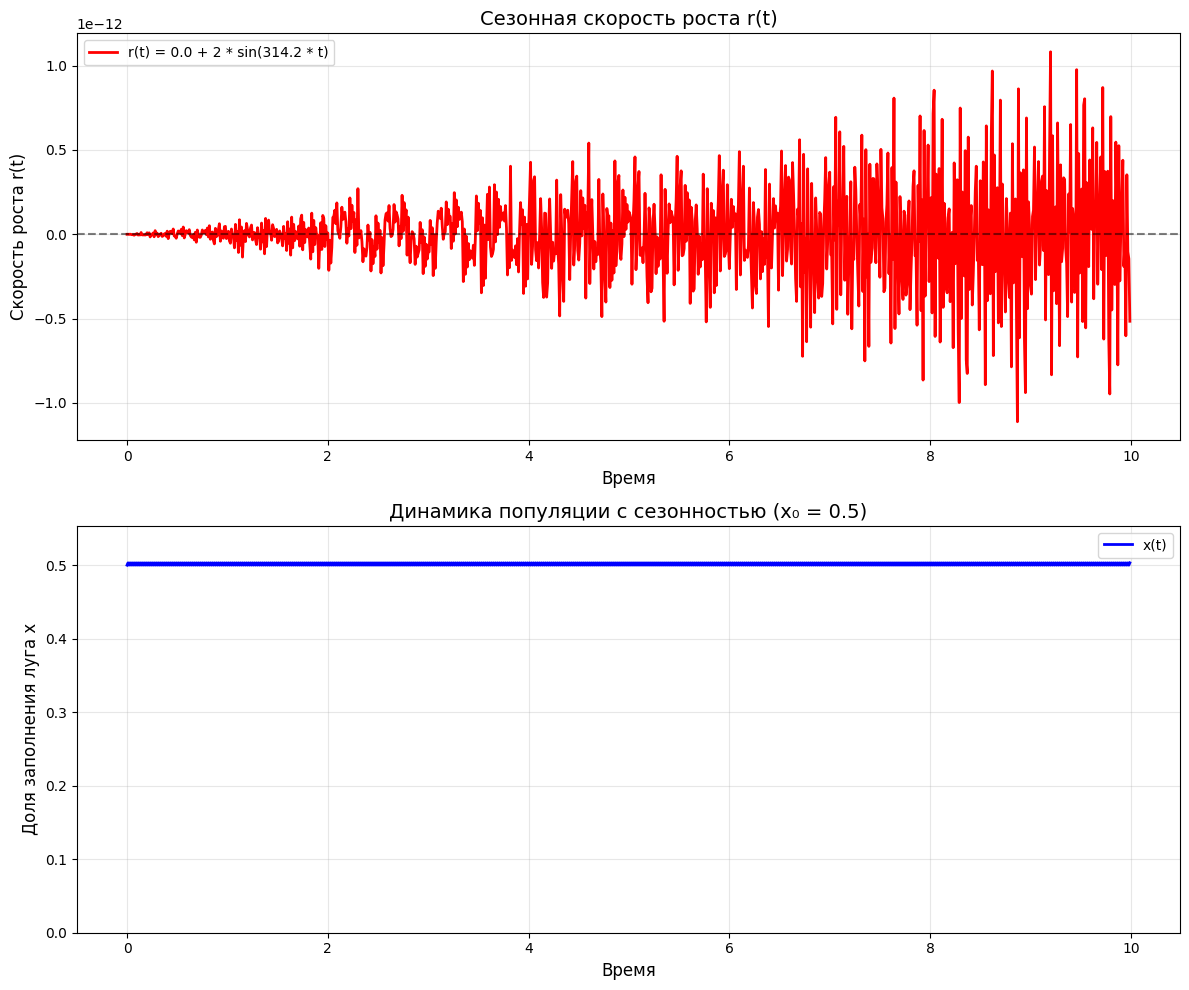

График сезонной модели сохранен как 'seasonal_logistic.png'

Анализ сезонной модели:
Минимальное значение x: 0.500
Максимальное значение x: 0.503
Среднее значение x: 0.502
Амплитуда колебаний: 0.003


In [ ]:

# Параметры сезонности
r0 = 1      # средняя скорость роста
ra = 0.6      # амплитуда сезонных колебаний
omega = 1  # частота (годовой цикл)

print("\n=== Модель с сезонностью ===")
print(f"r(t) = {r0} + {ra} * sin({omega:.1f} * t)")
print(f"Начальное условие: x₀ = {x0}")

# Решение с сезонностью
seasonal_solution = solve_seasonal_logistic_rk45(x0, r0, ra, omega, t_eval)

# Вычисление r(t) для графика
r_seasonal = r0 + ra * np.sin(omega * t_eval)

# Построение графиков для сезонной модели
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title('Сезонная скорость роста r(t)', fontsize=14)
ax1.plot(t_eval, r_seasonal, color='red', linewidth=2, label=f'r(t) = {r0} + {ra} * sin({omega:.1f} * t)')
ax1.set_xlabel('Время', fontsize=12)
ax1.set_ylabel('Скорость роста r(t)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=r0, color='black', linestyle='--', alpha=0.5, label=f'Среднее значение r₀ = {r0}')

ax2.set_title(f'Динамика популяции с сезонностью (x₀ = {x0})', fontsize=14)
ax2.plot(t_eval, seasonal_solution, color='blue', linewidth=2, label='x(t)')
ax2.set_xlabel('Время', fontsize=12)
ax2.set_ylabel('Доля заполнения луга x', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(0, max(seasonal_solution) * 1.1)

plt.tight_layout()
plt.savefig('seasonal_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сезонной модели сохранен как 'seasonal_logistic.png'")

# Анализ сезонной модели
print("\nАнализ сезонной модели:")
print(f"Минимальное значение x: {np.min(seasonal_solution):.3f}")
print(f"Максимальное значение x: {np.max(seasonal_solution):.3f}")
print(f"Среднее значение x: {np.mean(seasonal_solution):.3f}")
print(f"Амплитуда колебаний: {np.max(seasonal_solution) - np.min(seasonal_solution):.3f}")

## Выводы ##

## Выводы

В рамках этого занятия мы изучили экологическую модель логистического роста популяции травы на ограниченном лугу:

### Основные результаты:

1. **Логистическое уравнение** $x' = r x (1-x)$ правильно описывает динамику ограниченной популяции
   - При $r > 0$ популяция стремится к пределу экологической вместимости ($x = 1$)
   - При $r < 0$ популяция вымирает ($x = 0$)
   - Сходимость наблюдается независимо от начальных условий (для $0 < x_0 < 1$)

2. **Численное решение методом RK45** показало высокую точность и стабильность
   - Метод справляется с задачей для широкого диапазона параметров
   - Хорошо сохраняет асимптотическое поведение решения

3. **Сезонная модель** демонстрирует более сложную динамику
   - Популяция следует за сезонными изменениями скорости роста
   - Наблюдаются колебания вокруг некоторого среднего значения

### Методические замечания:

- Для решения ОДУ использовался метод Рунге-Кутты 4-5 порядка из scipy.integrate.solve_ivp
- Высокая точность достигнута за счет малого шага интегрирования и строгих tolerances
- Все графики сохранены в формате PNG для дальнейшего анализа